**CNN Architecture | Assignment**

Q1. What is the role of filters and feature maps in Convolutional Neural Network (CNN)?

A1. Filters (kernels) scan the input image to detect patterns such as edges, textures, and shapes using convolution operations. Each filter extracts a specific feature. The result of applying a filter is called a feature map, which highlights where that feature appears in the image, enabling the CNN to learn visual patterns automatically.


Q2. Explain the concepts of padding and stride in CNNs(Convolutional Neural Network). How do they affect the output dimensions of feature maps?

A2. Padding adds zeros around the input image to control border information and maintain output size. Stride is the number of pixels the filter moves during convolution.

Increasing padding increases or preserves output dimensions, while increasing stride reduces feature map size, lowers computation, and may lose some spatial detail.


Q3. Define receptive field in the context of CNNs. Why is it important for deep architectures?

A3. The receptive field is the region of the input image that a neuron in a CNN layer can see or respond to. In deep architectures, larger receptive fields allow the network to capture more global features and contextual information, improving the model’s ability to recognize complex patterns and objects accurately.


Q4. Discuss how filter size and stride influence the number of parameters in a CNN?

A4. The filter size directly affects the number of parameters—larger filters (e.g., 5×5) contain more weights than smaller filters (e.g., 3×3), increasing model complexity and computation. Stride does not change the number of parameters but affects the output feature map size, influencing computational cost and memory usage.

Q5. Compare and contrast different CNN-based architectures like LeNet, AlexNet, and VGG in terms of depth, filter sizes, and performance.

A5. LeNet is an early CNN architecture with about 5–7 layers, mainly used for handwritten digit recognition. It uses relatively larger filters like 5×5 and has low computational requirements.

AlexNet is deeper with 8 layers, introduced ReLU activation and dropout, and uses larger filters initially (11×11), achieving much better performance on complex image datasets.

VGG is significantly deeper (16–19 layers) and uses consistent 3×3 filters, which improves feature extraction and accuracy but increases computational cost and memory usage compared to LeNet and AlexNet.


Q6. Using keras, build and train a simple CNN model on the MNIST dataset from scratch. Include code for module creation, compilation, training, and evaluation.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [2]:
model = keras.Sequential([

    # Convolution Layer
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    # Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second Convolution Layer
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Output Layer (10 digits)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9585 - loss: 0.1376 - val_accuracy: 0.9852 - val_loss: 0.0538
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9861 - loss: 0.0459 - val_accuracy: 0.9885 - val_loss: 0.0363
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9907 - loss: 0.0299 - val_accuracy: 0.9885 - val_loss: 0.0382
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9930 - loss: 0.0210 - val_accuracy: 0.9882 - val_loss: 0.0464
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9943 - loss: 0.0167 - val_accuracy: 0.9917 - val_loss: 0.0360
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9906 - loss: 0.0306
Test Loss: 0.030572867020964622
Test Accuracy: 0.9905999898910522


Q7. Load and preprocess the CIFAR-10 dataset using Keras, and create a
CNN model to classify RGB images. Show your preprocessing and architecture.

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("Preprocessing completed.")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Preprocessing completed.


In [5]:
model = keras.Sequential([

    # Convolution Layer 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    # Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolution Layer 3
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),

    # Output Layer (10 classes)
    layers.Dense(10, activation='softmax')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4296 - loss: 1.5652 - val_accuracy: 0.5434 - val_loss: 1.2715
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5654 - loss: 1.2181 - val_accuracy: 0.5986 - val_loss: 1.1430
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6206 - loss: 1.0722 - val_accuracy: 0.6284 - val_loss: 1.0339
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6584 - loss: 0.9711 - val_accuracy: 0.6694 - val_loss: 0.9350
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6856 - loss: 0.8914 - val_accuracy: 0.6818 - val_loss: 0.9081
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7081 - loss: 0.8366 - val_accuracy: 0.6858 - val_loss: 0.8974
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7248 - loss: 0.7868 - val_accuracy: 0.6800 - val_loss: 0.9249
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7418 - loss: 0.7349 

Q8. Using PyTorch, write a script to define and train a CNN on the MNIST
dataset. Include model definition, data loaders, training loop, and accuracy evaluation.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.64MB/s]


In [8]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [9]:
model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

    model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Epoch [1/5], Loss: 0.1582
Epoch [2/5], Loss: 0.0470
Epoch [3/5], Loss: 0.0325
Epoch [4/5], Loss: 0.0238
Epoch [5/5], Loss: 0.0180
Test Accuracy: 98.62%


Q9. Given a custom image dataset stored in a local directory, write code using
Keras ImageDataGenerator to preprocess and train a CNN model.

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("princelv84/dogsvscats")

print("Path to dataset files:", path)

100%|██████████| 545M/545M [00:04<00:00, 126MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1


In [12]:
import os

print(os.listdir(path))
print(os.listdir(path + "/train"))

['test', 'train']
['cats', 'dogs']


In [13]:
train_dir = path + "/train"
val_dir = path + "/test"

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(150,150,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 219ms/step - accuracy: 0.6176 - loss: 0.6735 - val_accuracy: 0.6834 - val_loss: 0.5875
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.6947 - loss: 0.5825 - val_accuracy: 0.7466 - val_loss: 0.5220
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.7402 - loss: 0.5293 - val_accuracy: 0.7592 - val_loss: 0.4865
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.7636 - loss: 0.4921 - val_accuracy: 0.7878 - val_loss: 0.4522
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.7796 - loss: 0.4690 - val_accuracy: 0.7970 - val_loss: 0.4432


In [15]:
loss, accuracy = model.evaluate(validation_generator)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.7970 - loss: 0.4432
Test Accuracy: 0.796999990940094
Test Loss: 0.4432259202003479


In [16]:
model.save("cats_dogs_cnn_model.h5")

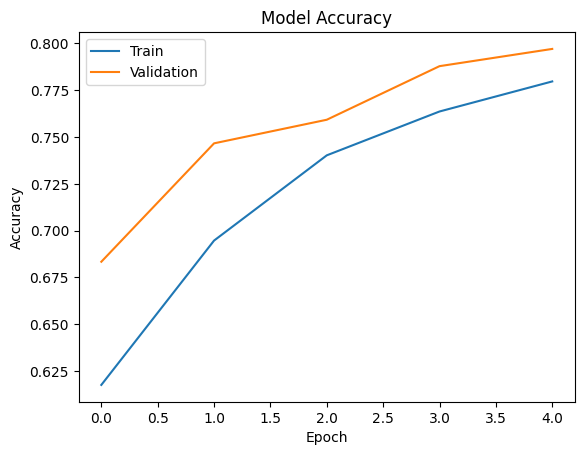

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

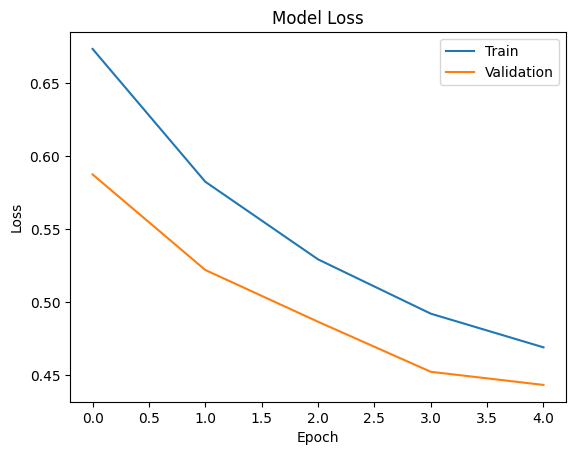

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])
plt.show()

Q10. You are working on a web application for a medical imaging startup. Your
task is to build and deploy a CNN model that classifies chest X-ray images into “Normal”
and “Pneumonia” categories. Describe your end-to-end approach–from data preparation
and model training to deploying the model as a web app using Streamlit.

In [19]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write("KGAT_2d74fcf249ccd66cf7b4c3e21636adb1")

os.chmod('/root/.kaggle/access_token', 0o600)

In [20]:
!pip install kaggle

In [21]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 136MB/s]



In [22]:
import zipfile

with zipfile.ZipFile(
    "chest-xray-pneumonia.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("/content/")

In [23]:
import os

print(os.listdir("/content/chest_xray"))

['chest_xray', 'test', 'train', '__MACOSX', 'val']


In [24]:
train_dir = "/content/chest_xray/train"
val_dir = "/content/chest_xray/val"
test_dir = "/content/chest_xray/test"

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 637ms/step - accuracy: 0.8390 - loss: 0.3808 - val_accuracy: 0.8125 - val_loss: 0.4387
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 606ms/step - accuracy: 0.8907 - loss: 0.2724 - val_accuracy: 0.8125 - val_loss: 0.5648
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 610ms/step - accuracy: 0.9015 - loss: 0.2365 - val_accuracy: 0.6250 - val_loss: 1.2741
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 597ms/step - accuracy: 0.9156 - loss: 0.2137 - val_accuracy: 0.6875 - val_loss: 0.8817
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 599ms/step - accuracy: 0.9227 - loss: 0.1866 - val_accuracy: 0.6875 - val_loss: 0.7962


In [29]:
loss, accuracy = model.evaluate(validation_generator)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6875 - loss: 0.7962
Test Accuracy: 0.6875


In [30]:
model.save("pneumonia_model.h5")

In [31]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.1 MB/s eta 0:00:00


In [32]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np

# Load trained model
model = tf.keras.models.load_model("pneumonia_model.h5")

st.title("Chest X-ray Pneumonia Detection")

uploaded_file = st.file_uploader(
    "Upload Chest X-ray Image",
    type=["jpg", "png", "jpeg"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file)
    image = image.resize((224,224))

    img_array = np.array(image) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        st.success("Prediction: Pneumonia")
    else:
        st.success("Prediction: Normal")

Writing app.py


In [33]:
from pyngrok import ngrok

ngrok.set_auth_token("2AXBiMs5PBwmFFBkCllTn2mMIis_7WDhxAkmkWWoUNmqpDSrc")

In [34]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://18e7-34-125-167-75.ngrok-free.app" -> "http://localhost:8501"
